# Deep Learning Models

Use this notebook to prototype neural network approaches for uplift modeling and individualized treatment effect estimation.

In [1]:
import torch
import torch.nn as nn
import math
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
import numpy as np

In [ ]:
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# ATARNet with Head-Specific Attention Pooling

This notebook implements a second version (we already did version one) of our Transformer-based TARNet model in PyTorch for uplift modeling on the Hillstrom dataset.

The model predicts the probability that a customer visits **with** and **without** receiving an email. The difference between these two probabilities represents the estimated individual treatment effect, or uplift.

The first ATARNet version replaced the traditional TARNet shared MLP representation network with a Transformer encoder. The Transformer produced one contextualized embedding for every customer feature, but mean pooling immediately compressed all feature embeddings into one shared customer representation. Both outcome heads therefore received exactly the same compressed vector.

In this second version, we remove that shared pooling bottleneck. We keep the complete contextualized feature map and give each potential-outcome head its own attention-pooling layer. The control head and treatment head can therefore learn different weighted summaries of the same contextualized features before predicting their respective outcomes.

# 1. Define the Neural Network Architecture

This section defines all the PyTorch classes required to build the new ATARNet model.

The architecture converts customer features into feature embeddings, learns interactions between those features using self-attention, and estimates the potential outcomes under both treatment and control, each head learns its own attention-weighted customer representation.

## Model Components

- **FeatureTokenizer**
  - Converts every numerical and categorical feature into a token with the same embedding dimension.
  - An important distinction is that we dont need to transform the categorical variables into dummy ones anymore as we did with the Causation Tree model. We think that by doing this we can retain more information about the relationship between different groups of categorical variables such as channel vs zip_code.

- **SelfAttentionHead**
  - Allows every feature token to use information from every other feature token.

- **MultiHeadSelfAttention**
  - Uses several self-attention heads so the model can learn different types of feature interactions.

- **Transformer**
  - Applies self-attention, residual connections, layer normalization, and a feed-forward network.

- **AttentionPooling**
  - Assigns one learned importance score to every contextualized feature token.
  - Converts the scores into weights with softmax.
  - Calculates a weighted average of the feature tokens.

- **OutcomeHead**
  - Contains its own attention-pooling layer and MLP.
  - The control and treatment heads therefore construct different customer representations.

- **ATARNet**
  - Combines the shared tokenizer and Transformer with the two head-specific outcome networks.

- **Loss**
  - Uses the standard actual TARNet loss. For each customer, only the output corresponding to the treatment actually observed contributes to the loss.

## Model Architecture


ATARNet
│
├── FeatureTokenizer
│
├──── Transformer
│     ├── MultiHeadSelfAttention
│     │   └──SelfAttentionHead
│     │
│     ├── FeedForward
│     ├── LayerNorm
│     └── Residual connections
│   
│
├── control_head (OutcomeHead)
│   ├── AttentionPooling
│   └── MLP
│
└── treatment_head (OutcomeHead)
    ├── AttentionPooling
    └── MLP


```text
Raw Features
      │
      ▼
Feature Tokenizer
      │
      ▼
Transformer Encoder
      │
      ▼
Contextualized Feature Map
      │
      ├──────────────────────┐
      ▼                      ▼
Control Attention     Treatment Attention
Pooling               Pooling
      │                      │
      ▼                      ▼
Control Representation Treatment Representation
      │                      │
      ▼                      ▼
Control MLP            Treatment MLP
      │                      │
      ▼                      ▼
    μ̂₀(x)                   μ̂₁(x)
             │
             ▼
     Uplift = μ̂₁(x) − μ̂₀(x)
```

The Transformer is still shared because both potential outcomes should benefit from learning general relationships among customer features. The pooling and prediction layers are separate because the two potential outcomes may depend on those relationships differently.


In [2]:
class FeatureTokenizer(nn.Module):
    def __init__(
        self,
        num_features: int,
        cat_features: list[int],
        token_dim: int,
    ):
        """
        Convert each original feature into one token
        Args:
            B: number of customers
            F:num_features+cat_features
            D: token_dim    
        """
        super().__init__()
        self.num_features = num_features
        self.num_cat_features = len(cat_features)
        self.token_dim = token_dim
        #one vector and bias for each numerical feature
        self.num_weights = nn.Parameter(torch.empty(num_features, token_dim))#(N_num,D)
        self.num_biases = nn.Parameter(torch.empty(num_features, token_dim))#(N_num,D)
        #one embedding table for each categorical feature.
        #each embedding produce vector of size D
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=i,embedding_dim=token_dim,)for i in cat_features])
        #we fill the vector with random small numbers
        #we cant fill them with zero because of the problems we learned in class
        self.initialize_parameters()

    def initialize_parameters(self):
        """
        initialize the parameters with small random numbers
        Xavier initialization chooses a variance that approximately keeps 
        the magnitude of activations constant as they flow through the network
        """
        nn.init.xavier_uniform_(self.num_weights)
        nn.init.zeros_(self.num_biases)
        for j in self.cat_embeddings:
            nn.init.xavier_uniform_(j.weight)

    def forward(
        self,
        num_inputs: torch.Tensor,
        cat_inputs: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            num_inputs (B,N_num)
            cat_inputs (B,N_cat)
        Returns:
            feature_tokens. One token per original feature (B,N_num+N_cat,D)
        """
        num_values = num_inputs.unsqueeze(-1)#(B,N_num)(B,N_num,1)
        num_tokens = (num_values*self.num_weights+self.num_biases)#Broadcasting:(B,N_num,1)*(N_num,D)=(B,N_num,D)
        cat_tokens = []
        for feature_index,embedding in enumerate(self.cat_embeddings):#categorical_inputs[:,feature_index](B,)
            token = embedding(cat_inputs[:,feature_index])#embedding output(B,D)
            cat_tokens.append(token)
        # List of N_cat tensors(B,D)
        # Stack them along the feature dimension(B,N_cat,D)
        cat_tokens = torch.stack(cat_tokens,dim=1,)
        # Numerical tokens(B,N_num,D)+Categorical tokens(B,N_cat,D)=(B,N_num+N_cat,D)
        feature_tokens = torch.cat([num_tokens,cat_tokens,],dim=1,)

        return feature_tokens

In [3]:
batch_size=5
token_dim=16

In [4]:
tokenizer=FeatureTokenizer(
    num_features=4,
    cat_features=[7,3,2,3],
    token_dim=token_dim,
)

In [5]:
num_inputs=torch.randn(batch_size,4)

In [6]:
cat_inputs=torch.tensor(
    [
        [0,1,0,2],
        [3,0,1,1],
        [5,2,0,0],
        [1,1,1,2],
        [6,0,0,1],
    ],
    dtype=torch.long,
)

In [7]:
feature_tokens=tokenizer(
    num_inputs,
    cat_inputs,
)

In [8]:
feature_tokens.shape

torch.Size([5, 8, 16])

In [9]:
class SelfAttentionHead(nn.Module):
    def __init__(
        self,
        token_dim: int,
        head_dim: int,
    ):
        """
        Args:
            D: token_dim
            H: head_dim size of the query, key, and value vectors.
        """
        super().__init__()
        self.head_dim = head_dim
        self.q_layer = nn.Linear(token_dim,head_dim)
        self.k_layer = nn.Linear(token_dim,head_dim)
        self.v_layer = nn.Linear(token_dim,head_dim)

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            attention_output (B,F,H)
        """
        # Each feature token becomes a query, key, value
        q = self.q_layer(feature_tokens)#(B,F,D) (B,F,H)
        k = self.k_layer(feature_tokens)
        v = self.v_layer(feature_tokens)
        #Compare every query with every key
        scores = torch.matmul(q,k.transpose(1, 2),)#(B,F,H)(B,H,F) (B,F,F)
        #Prevent the dot products from becoming too large.
        scores = scores/math.sqrt(self.head_dim)
        #scores into probabilities
        attention_weights = torch.softmax(scores,dim=-1,)
        #Calculate a weighted average of the value vectors
        attention_output = torch.matmul(attention_weights,v,)#(B,F,F)(B,F,H) (B,F,H)

        return attention_output

In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        token_dim: int,
        num_heads: int,
    ):
        """
        Args:
            D: token_dim
            num_heads
        """
        super().__init__()
        assert token_dim % num_heads == 0# just checking that we didnt messed up the head number
        self.token_dim = token_dim
        self.num_heads = num_heads
        self.head_dim = token_dim//num_heads
        #Create attention heads
        self.heads = nn.ModuleList([SelfAttentionHead(token_dim=token_dim,head_dim=self.head_dim,)
                for _ in range(num_heads)])
        self.output_layer = nn.Linear(token_dim,token_dim,)#Combine heads

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            output(B,F,D)
        """
        head_outputs = []
        for head in self.heads:# Each head (B,F,D) (B,F,H)
            head_output = head(feature_tokens)
            head_outputs.append(head_output)
        combined_heads = torch.cat(head_outputs,dim=-1,)#(B,F,H*num_heads)
        output = self.output_layer(combined_heads)#(B,F,D)

        return output

In [11]:
multi_head_attention = MultiHeadSelfAttention(token_dim=16,num_heads=4,)

In [12]:
attention_output = multi_head_attention(feature_tokens)

In [13]:
print(feature_tokens.shape)
print(attention_output.shape)

torch.Size([5, 8, 16])
torch.Size([5, 8, 16])


In [14]:
residual_output = feature_tokens + attention_output

In [15]:
residual_output.shape

torch.Size([5, 8, 16])

In [16]:
layer_norm = nn.LayerNorm(16)
normalized_output = layer_norm(residual_output)

In [17]:
normalized_output.shape

torch.Size([5, 8, 16])

In [18]:
feed_forward_1 = nn.Linear(16,32)
relu = nn.ReLU()
feed_forward_2 = nn.Linear(32,16)
feed_forward_output = feed_forward_1(normalized_output)
print(feed_forward_output.shape)  # (5,8,32)
feed_forward_output = relu(feed_forward_output)
print(feed_forward_output.shape)  # (5,8,32)
feed_forward_output = feed_forward_2(feed_forward_output)
print(feed_forward_output.shape)  # (5,8,16)

torch.Size([5, 8, 32])
torch.Size([5, 8, 32])
torch.Size([5, 8, 16])


In [19]:
second_residual = normalized_output + feed_forward_output

In [20]:
layer_norm_2 = nn.LayerNorm(16)
transformer_output = layer_norm_2(second_residual)

print(transformer_output.shape)

torch.Size([5, 8, 16])


In [21]:
class Transformer(nn.Module):
    def __init__(
        self,
        token_dim: int,
        num_heads: int,
        hidden_dim: int,
    ):
        super().__init__()
        self.attention = MultiHeadSelfAttention(token_dim=token_dim,num_heads=num_heads,)
        self.norm1 = nn.LayerNorm(token_dim)
        self.linear1 = nn.Linear(token_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, token_dim)
        self.norm2 = nn.LayerNorm(token_dim)

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            output(B,F,D)
        """
        # Multi-head self-attention
        attention_output = self.attention(feature_tokens)#(B,F,D)
        residual1 = (feature_tokens+attention_output)#(B,F,D)
        normalized1 = self.norm1(residual1)# (B,F,D)
        feed_forward = self.linear1(normalized1)#(B,F,D) (B,F,hidden_dim)
        feed_forward = self.relu(feed_forward)#(B,F,hidden_dim)
        feed_forward = self.linear2(feed_forward)#(B,F,hidden_dim) (B,F,D)
        residual2 = (normalized1+feed_forward)# (B,F,D)
        output = self.norm2(residual2)# (B,F,D)

        return output

In [22]:
transformer = Transformer(token_dim=16,num_heads=4,hidden_dim=32,)

In [23]:
transformer_output = transformer(feature_tokens)

In [24]:
feature_tokens.shape

torch.Size([5, 8, 16])

In [25]:
transformer_output.shape

torch.Size([5, 8, 16])

## Head-Specific Attention Pooling

The Transformer output has shape `(B,F,D)`:

- `B` is the number of customers in the batch.
- `F` is the number of original features.
- `D` is the token dimension.

In the first model, `mean(dim=1)` gave every feature the same weight and produced one shared vector. We now learn those weights instead.

For every feature token, the pooling layer produces one score. Softmax converts the `F` scores into weights that add to one. The final representation is the weighted sum of the contextualized feature tokens.

Each outcome head receives a separate instance of this layer, so its scoring parameters are independent.


In [26]:
class AttentionPooling(nn.Module):
    def __init__(
        self,
        token_dim: int,
        hidden_dim: int,
    ):
        super().__init__()
        self.linear1 = nn.Linear(token_dim,hidden_dim)
        self.tanh = nn.Tanh()
        self.linear2 = nn.Linear(hidden_dim,1)

    def forward(
        self,
        contextualized_tokens: torch.Tensor,
    ):
        """
        Args:
            contextualized_tokens(B,F,D)
        Returns:
            customer_representation(B,D)
            attention_weights(B,F)
        """
        scores = self.linear1(contextualized_tokens)#(B,F,D) (B,F,H)
        scores = self.tanh(scores)#(B,F,H)
        scores = self.linear2(scores)#(B,F,H) (B,F,1)
        attention_weights = torch.softmax(scores,dim=1,)#(B,F,1)
        weighted_tokens = contextualized_tokens*attention_weights#(B,F,D)
        customer_representation = weighted_tokens.sum(dim=1)#(B,D)

        return customer_representation,attention_weights.squeeze(-1)


In [27]:
attention_pooling = AttentionPooling(token_dim=16,hidden_dim=16,)
customer_representation, attention_weights = attention_pooling(transformer_output)

print(customer_representation.shape)
print(attention_weights.shape)
print(attention_weights.sum(dim=1))

torch.Size([5, 16])
torch.Size([5, 8])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


The attention weights have shape `(B,F)`. Each row contains one weight per feature and adds to one.

These weights are not automatically a causal explanation of the prediction. They show how the pooling layer combines the already contextualized tokens. Because each token already contains information from the other features, a large weight for one token does not mean that only its original raw feature mattered.


In [28]:
class OutcomeHead(nn.Module):
    def __init__(
        self,
        token_dim: int,
        pooling_hidden_dim: int,
        outcome_hidden_dim: int,
    ):
        super().__init__()
        self.pooling = AttentionPooling(token_dim=token_dim,hidden_dim=pooling_hidden_dim,)
        self.linear1 = nn.Linear(token_dim,outcome_hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(outcome_hidden_dim,1)

    def forward(
        self,
        contextualized_tokens: torch.Tensor,
    ):
        """
        Args:
            contextualized_tokens (B,F,D)
        Returns:
            logits (B,1)
            attention_weights (B,F)
        """
        customer_representation,attention_weights = self.pooling(contextualized_tokens)
        x = self.linear1(customer_representation)#(B,D) (B,H)
        x = self.relu(x)#(B,H)
        logits = self.linear2(x)#(B,H) (B,1)

        return logits,attention_weights

In [29]:
control_head = OutcomeHead(token_dim=16,pooling_hidden_dim=16,outcome_hidden_dim=16,)
treatment_head = OutcomeHead(token_dim=16,pooling_hidden_dim=16,outcome_hidden_dim=16,)

In [30]:
control_logits,control_attention = control_head(transformer_output)
treatment_logits,treatment_attention = treatment_head(transformer_output)

print(control_logits.shape)
print(treatment_logits.shape)
print(control_attention.shape)
print(treatment_attention.shape)

torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 8])
torch.Size([5, 8])


In [31]:
control_probability = torch.sigmoid(control_logits)
treatment_probability = torch.sigmoid(treatment_logits)
uplift = treatment_probability-control_probability

In [32]:
print(control_probability.shape)
print(treatment_probability.shape)
print(uplift.shape)

torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])


The two heads see the same contextualized feature map, but they do not receive the same customer representation. Their separate pooling layers can assign different weights to the feature tokens.

This is the key change from the first ATARNet version.


In [33]:
class ATARNet(nn.Module):
    def __init__(
        self,
        num_features: int,
        cat_features: list[int],
        token_dim: int,
        num_heads: int,
        transformer_hidden_dim: int,
        pooling_hidden_dim: int,
        outcome_hidden_dim: int,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features=num_features,cat_features=cat_features,token_dim=token_dim,)
        self.transformer = Transformer(token_dim=token_dim,num_heads=num_heads,hidden_dim=transformer_hidden_dim,)
        self.control_head = OutcomeHead(token_dim=token_dim,pooling_hidden_dim=pooling_hidden_dim,outcome_hidden_dim=outcome_hidden_dim,)
        self.treatment_head = OutcomeHead(token_dim=token_dim,pooling_hidden_dim=pooling_hidden_dim,outcome_hidden_dim=outcome_hidden_dim,)

    def forward(
        self,
        num_inputs: torch.Tensor,
        cat_inputs: torch.Tensor,
        return_attention: bool=False,
    ):
        feature_tokens = self.tokenizer(num_inputs,cat_inputs,)#(B,N_num)(B,N_cat) (B,F,D)
        contextualized_tokens = self.transformer(feature_tokens)#(B,F,D)
        control_logits,control_attention = self.control_head(contextualized_tokens)
        treatment_logits,treatment_attention = self.treatment_head(contextualized_tokens)

        if return_attention:
            return (
                control_logits,
                treatment_logits,
                control_attention,
                treatment_attention,
            )

        return control_logits,treatment_logits


In [34]:
model = ATARNet(
    num_features=4,
    cat_features=[7,3,2,3],
    token_dim=16,
    num_heads=4,
    transformer_hidden_dim=32,
    pooling_hidden_dim=16,
    outcome_hidden_dim=16,
)
(control_logits,treatment_logits,control_attention,treatment_attention,) = model(num_inputs,cat_inputs,return_attention=True,)

print(control_logits.shape)
print(treatment_logits.shape)
print(control_attention.shape)
print(treatment_attention.shape)

torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 8])
torch.Size([5, 8])


In [35]:
def ATARNetloss(control_logits: torch.Tensor,treatment_logits: torch.Tensor,treatment: torch.Tensor,outcome: torch.Tensor,
) -> torch.Tensor:
    loss_function = nn.BCEWithLogitsLoss(reduction="none")
    control_loss = loss_function(control_logits,outcome,)
    treatment_loss = loss_function(treatment_logits,outcome,)
    actual_loss = (1-treatment)*control_loss+treatment*treatment_loss

    return actual_loss.mean()

In [36]:
treatment = torch.tensor(
    [[0],
     [1],
     [1],
     [0],
     [1]],
    dtype=torch.float32,
)



In [37]:
outcome = torch.tensor(
    [[0],
     [1],
     [0],
     [0],
     [1]],
    dtype=torch.float32,
)

In [38]:
loss = ATARNetloss(
    control_logits,
    treatment_logits,
    treatment,
    outcome,
)

print("Loss:", loss.item())

Loss: 0.6779381632804871


In [39]:
model.zero_grad()
loss.backward()

In [40]:
data_path = Path("../data/raw/hillstrom_email.csv")
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path.resolve()}"
    )

df = pd.read_csv(data_path)
print(f"Loaded {data_path.name} with shape {df.shape}")

Loaded hillstrom_email.csv with shape (64000, 12)


In [41]:
# ============================================
# Unit 1: Define columns
# ============================================
numerical_columns = [
    "recency",
    "history",
    "mens",
    "womens",
]
categorical_columns = [
    "history_segment",
    "zip_code",
    "newbie",
    "channel",
]
treatment_column = "treatment"
outcome_column = "visit"

In [42]:
df["treatment"]=(df["segment"]!="No E-Mail").astype(int)

In [43]:
# ============================================
# Unit 2: Train/test split
# ============================================
train_df, test_df = train_test_split(df,test_size=0.2,random_state=42,stratify=df["treatment"],)
train_df = train_df.copy()
test_df = test_df.copy()
print("Training rows", len(train_df))
print("Testing rows", len(test_df))

Training rows 51200
Testing rows 12800


In [44]:
# ============================================
# Unit 3: Numerical preprocessing
# ============================================
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numerical_columns])
X_num_test = scaler.transform(test_df[numerical_columns])

print("Numerical train shape", X_num_train.shape)
print("Numerical test shape", X_num_test.shape)

Numerical train shape (51200, 4)
Numerical test shape (12800, 4)


In [45]:
# ============================================
# Unit 4: Categorical preprocessing
# ============================================
category_mappings = {}
categorical_cardinalities = []
for column in categorical_columns:
    categories = train_df[column].unique().tolist()#Unique training categories
    mapping = {category:index for index, category in enumerate(categories)}
    category_mappings[column] = mapping
    categorical_cardinalities.append(len(mapping))# Number of possible categories for this feature
    train_df[column+"_id"] = train_df[column].map(mapping)
    test_df[column+"_id"] = test_df[column].map(mapping)

print("Categorical cardinalities", categorical_cardinalities)

Categorical cardinalities [7, 3, 2, 3]


In [46]:
categorical_id_columns = [column+"_id" for column in categorical_columns]

X_cat_train = train_df[categorical_id_columns].to_numpy()
X_cat_test = test_df[categorical_id_columns].to_numpy()

print("Categorical train shape", X_cat_train.shape)
print("Categorical test shape", X_cat_test.shape)

Categorical train shape (51200, 4)
Categorical test shape (12800, 4)


In [47]:
# ============================================
# Unit 5: Treatment and outcome
# ============================================
T_train = train_df[treatment_column].to_numpy().reshape(-1,1)
T_test = test_df[treatment_column].to_numpy().reshape(-1,1)
Y_train = train_df[outcome_column].to_numpy().reshape(-1,1)
Y_test = test_df[outcome_column].to_numpy().reshape(-1,1)

print("T train shape", T_train.shape)
print("Y train shape", Y_train.shape)

print("Treatment values", set(T_train.flatten()))
print("Outcome values", set(Y_train.flatten()))

T train shape (51200, 1)
Y train shape (51200, 1)
Treatment values {0, 1}
Outcome values {0, 1}


In [48]:
# ============================================
# Unit 6: Convert arrays to tensors
# ============================================
X_num_train_tensor = torch.tensor(X_num_train,dtype=torch.float32,)
X_cat_train_tensor = torch.tensor(X_cat_train,dtype=torch.long,)
T_train_tensor = torch.tensor(T_train,dtype=torch.float32,)
Y_train_tensor = torch.tensor(Y_train,dtype=torch.float32,)
X_num_test_tensor = torch.tensor(X_num_test,dtype=torch.float32,)
X_cat_test_tensor = torch.tensor(X_cat_test,dtype=torch.long,)
T_test_tensor = torch.tensor(T_test,dtype=torch.float32,)
Y_test_tensor = torch.tensor(Y_test,dtype=torch.float32,)

In [49]:
print("X_num_train", X_num_train_tensor.shape)
print("X_cat_train", X_cat_train_tensor.shape)
print("T_train", T_train_tensor.shape)
print("Y_train", Y_train_tensor.shape)

X_num_train torch.Size([51200, 4])
X_cat_train torch.Size([51200, 4])
T_train torch.Size([51200, 1])
Y_train torch.Size([51200, 1])


In [50]:
# ============================================
# Unit 7: Create TensorDataset
# ============================================
train_dataset = TensorDataset(
    X_num_train_tensor,
    X_cat_train_tensor,
    T_train_tensor,
    Y_train_tensor,
)
test_dataset = TensorDataset(
    X_num_test_tensor,
    X_cat_test_tensor,
    T_test_tensor,
    Y_test_tensor,
)
print("Training samples", len(train_dataset))
print("Testing samples", len(test_dataset))

Training samples 51200
Testing samples 12800


In [51]:
# ============================================
# Unit 8: Create DataLoaders
# ============================================


if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

generator = torch.Generator()
generator.manual_seed(seed)
batch_size=256
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [52]:
batch = next(iter(train_loader))

num_batch = batch[0]
cat_batch = batch[1]
treatment_batch = batch[2]
outcome_batch = batch[3]

print("Numerical batch", num_batch.shape)
print("Categorical batch", cat_batch.shape)
print("Treatment batch", treatment_batch.shape)
print("Outcome batch", outcome_batch.shape)

Numerical batch torch.Size([256, 4])
Categorical batch torch.Size([256, 4])
Treatment batch torch.Size([256, 1])
Outcome batch torch.Size([256, 1])


In [53]:
# ============================================
# Unit 9: Select device
# ============================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cpu


In [54]:
# ============================================
# Unit 10: Create model
# ============================================
torch.manual_seed(seed)
model = ATARNet(
    num_features=len(numerical_columns),
    cat_features=categorical_cardinalities,
    token_dim=16,
    num_heads=4,
    transformer_hidden_dim=32,
    pooling_hidden_dim=16,
    outcome_hidden_dim=16,
)
model = model.to(device)
print(model)


ATARNet(
  (tokenizer): FeatureTokenizer(
    (cat_embeddings): ModuleList(
      (0): Embedding(7, 16)
      (1): Embedding(3, 16)
      (2): Embedding(2, 16)
      (3): Embedding(3, 16)
    )
  )
  (transformer): Transformer(
    (attention): MultiHeadSelfAttention(
      (heads): ModuleList(
        (0-3): 4 x SelfAttentionHead(
          (q_layer): Linear(in_features=16, out_features=4, bias=True)
          (k_layer): Linear(in_features=16, out_features=4, bias=True)
          (v_layer): Linear(in_features=16, out_features=4, bias=True)
        )
      )
      (output_layer): Linear(in_features=16, out_features=16, bias=True)
    )
    (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (linear1): Linear(in_features=16, out_features=32, bias=True)
    (relu): ReLU()
    (linear2): Linear(in_features=32, out_features=16, bias=True)
    (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (control_head): OutcomeHead(
    (pooling): AttentionPooling(
     

In [55]:
# ============================================
# Unit 11: Optimizer
# ============================================
optimizer = torch.optim.Adam(model.parameters(),lr=0.0005,)

In [56]:
# ============================================
# Unit 12: Training loop
# ============================================
number_of_epochs = 20
train_losses = []
for epoch in range(number_of_epochs):
    model.train()
    total_loss = 0.0
    for (num_batch,cat_batch,treatment_batch,outcome_batch,) in train_loader:
        # Move the batch to the selected device
        num_batch = num_batch.to(device)
        cat_batch = cat_batch.to(device)
        treatment_batch = treatment_batch.to(device)
        outcome_batch = outcome_batch.to(device)
        # Remove gradients from the previous batch
        optimizer.zero_grad()
        # Forward pass
        control_logits, treatment_logits = model(num_batch,cat_batch,)
        # Factual TARNet loss
        loss = ATARNetloss(control_logits,treatment_logits,treatment_batch,outcome_batch,)
        # Calculate gradients
        loss.backward()
        # Update model parameters
        optimizer.step()
        total_loss+=loss.item()*len(num_batch)
    average_train_loss=total_loss/len(train_dataset)
    train_losses.append(average_train_loss)

    print(f"Epoch {epoch + 1:02d} | "
        f"Training loss: {average_train_loss:.4f}")

Epoch 01 | Training loss: 0.4429
Epoch 02 | Training loss: 0.4034
Epoch 03 | Training loss: 0.4008
Epoch 04 | Training loss: 0.4001
Epoch 05 | Training loss: 0.4000
Epoch 06 | Training loss: 0.3999
Epoch 07 | Training loss: 0.3994
Epoch 08 | Training loss: 0.3995
Epoch 09 | Training loss: 0.3996
Epoch 10 | Training loss: 0.3997
Epoch 11 | Training loss: 0.3992
Epoch 12 | Training loss: 0.3993
Epoch 13 | Training loss: 0.3995
Epoch 14 | Training loss: 0.3992
Epoch 15 | Training loss: 0.3990
Epoch 16 | Training loss: 0.3992
Epoch 17 | Training loss: 0.3991
Epoch 18 | Training loss: 0.3990
Epoch 19 | Training loss: 0.3990
Epoch 20 | Training loss: 0.3993


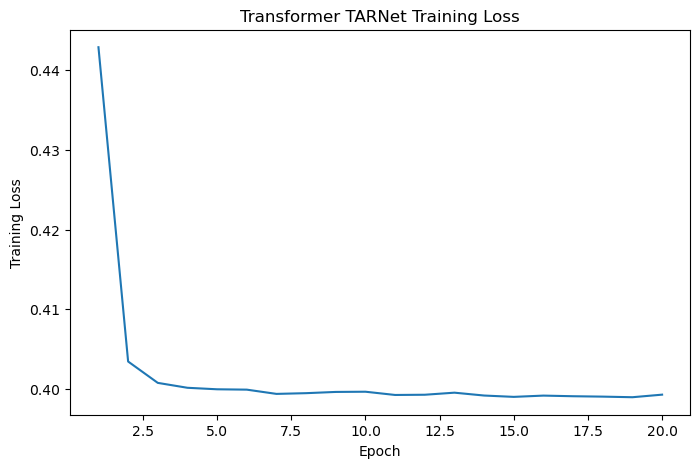

In [57]:
# ============================================
# Unit 13: Plot training loss
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(range(1,number_of_epochs+1),train_losses,)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer TARNet Training Loss")

plt.show()

In [58]:
# ============================================
# Unit 14: Generate test predictions
# ============================================
model.eval()

all_control_probabilities = []
all_treatment_probabilities = []

with torch.no_grad():
    for (num_batch,cat_batch,treatment_batch,outcome_batch,) in test_loader:

        num_batch = num_batch.to(device)
        cat_batch = cat_batch.to(device)

        control_logits,treatment_logits=model(num_batch,cat_batch,)
        control_probabilities = torch.sigmoid(control_logits)
        treatment_probabilities = torch.sigmoid(treatment_logits)
        all_control_probabilities.append(control_probabilities.cpu())
        all_treatment_probabilities.append(treatment_probabilities.cpu())

In [59]:
control_probability_test = torch.cat(all_control_probabilities,dim=0,)
treatment_probability_test = torch.cat(all_treatment_probabilities,dim=0,)
uplift_test = (treatment_probability_test-control_probability_test)

print("Control prob", control_probability_test.shape)
print("Treatment prob", treatment_probability_test.shape)
print("Uplift", uplift_test.shape)

Control prob torch.Size([12800, 1])
Treatment prob torch.Size([12800, 1])
Uplift torch.Size([12800, 1])


In [60]:
# ============================================
# Unit 15: Inspect predictions
# ============================================
print("Average predicted control prob ",control_probability_test.mean().item(),)
print("Average predicted treatment prob ",treatment_probability_test.mean().item(),)
print("Average predicted uplift",uplift_test.mean().item(),)
print("Minimum predicted uplift",uplift_test.min().item(),)
print("Maximum predicted uplift",uplift_test.max().item(),)

Average predicted control prob  0.11502303183078766
Average predicted treatment prob  0.1860785335302353
Average predicted uplift 0.07105550169944763
Minimum predicted uplift 0.018301434814929962
Maximum predicted uplift 0.15426573157310486


# 3. How This Architecture Relates to Existing Work

This model combines familiar ideas in a new arrangement rather than introducing an entirely new attention mechanism.

## Attention Pooling

The new layer is a standard learned attention-pooling mechanism. Instead of using a fixed mean, a small neural network scores every contextualized token and softmax creates a weighted average. The distinctive choice in this notebook is to give the two TARNet potential-outcome heads separate pooling parameters.

## Set Transformer

The Set Transformer also uses attention to encode interactions among a set of elements and introduces attention-based pooling with learned seed vectors. Our design resembles its general idea of using attention to summarize a collection of representations. However, this implementation is simpler: it uses one scalar score per token rather than a full multi-head attention decoder with learned seed vectors.

## Perceiver

The Perceiver uses cross-attention from a small latent array to a much larger input in order to create a compact latent bottleneck. Our attention pooler also compresses many tokens into one representation, but it does not use iterative latent cross-attention and is not motivated by long-input computational scaling. The resemblance is therefore conceptual rather than architectural.

## Tabular Transformers

TabTransformer and FT-Transformer established the broader pattern of representing columns as tokens and applying self-attention across features. Our shared tokenizer and Transformer follow that family of ideas. The head-specific pooling is added specifically for the two-potential-outcome structure of TARNet.

## Uplift Modeling

TARNet uses a shared representation followed by separate outcome heads. DragonNet adds a propensity head and targeted regularization, while CFR-style models add representation-balancing objectives. Our model keeps the standard TARNet factual objective and changes how each outcome head summarizes the shared Transformer feature map.

## Is It Novel?

The safest description is **a head-specific attention-pooling variation of Transformer-based TARNet**.

The individual building blocks are not novel: feature tokenization, Transformer encoders, attention pooling, and separate potential-outcome heads all exist. The particular combination—separate treatment-specific and control-specific attention poolers over one shared contextualized tabular feature map—may be less common, but a proper novelty claim would require a broader systematic literature review and direct comparison with recent uplift architectures.

For this project, it is reasonable to present the contribution as an architectural hypothesis:

> A shared Transformer learns general feature interactions, while treatment-specific attention pooling allows each potential-outcome head to construct the representation most useful for its own prediction task.

That claim accurately describes what the model does without overstating novelty.
